In [ ]:
#!pip install yfinance

In [8]:
import yfinance as yf
import pandas as pd
from IPython.display import display, HTML

display(HTML("<style>.container { width:90% ! important; }</style>"))

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [9]:
#cob_date = '2025-04-01'  # Change this to the desired date

cob_date = '2025-12-31'  # Change this to the desired date

#cob_date = datetime.today().strftime('%Y-%m-%d')
cob_date_dt = datetime.strptime(cob_date, '%Y-%m-%d')
year_end_date = (cob_date_dt).replace(day=1, month=1) - timedelta(days=1)

print(f"Calculating for COB date: {cob_date}")
print(f"Year end date derived from COB date: {year_end_date.strftime('%Y-%m-%d')}")

Calculating for COB date: 2025-12-31
Year end date derived from COB date: 2024-12-31


In [10]:
# Define the indices and their tickers
indices = {
    "US Equities": ["^GSPC", "^DJI", "^IXIC", "^RUT","^VIX"],
    "US Cyclic Sectors ": ["XLB", "XLI", "XLK", "XLY", "XLF", "XLC" ],  # Example: S&P Sector ETFs
    "US Defensive Sectors": ["XLRE", "XLP" ,"XLE", "XLV", "XLU" ],  # Note: S&P sector ETFs are used here for cyclic sectors
    "Ex US Equities": ["^FTSE", "^FCHI", "^GDAXI" , "^N225", "^HSI" ,"^NSEI"],  # Example: FTSE 100, Nikkei 225, NSE India, Hang Seng Index
    "US Rates": ["^IRX", "^FVX", "^TNX", "^TYX"],
   # "Credit": ["LQD", "HYG", "JNK"],
    "FX": ["EURUSD=X", "JPY=X", "GBPUSD=X", "USDCNY=X"],
    "Commodity": ["CL=F", "NG=F" , "GC=F", "SI=F", "HG=F"],
    "Crypto": ["BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD"]  
}

ticker_names = {
"^GSPC": "S&P 500",
"^DJI":  "Dow Jones",
"^IXIC": "Nasdaq Composite",
"^RUT":  "Russell 2000", 
"^VIX":   "CBOE Volatility Index",  # Example: VIX Index


# US Cyclic Sector Indices
# Note: These are ETFs that track S&P sector indices
"XLB": "Materials",  # Materials
"XLI": "Industrial",  # Industrials
"XLK": "Technology",  # Technology (Note: XLT is not an official S&P sector ETF, but commonly used for tech)
"XLY": "Cons. Disc.",  # Consumer Discretionary
"XLF": "Financial",  # Financials 
"XLC": "Comm. Services",  # Communication Services  


# US Defensive Sector Indices
"XLRE": "Real Estate",  # Real Estate (not an official S&P sector but commonly used)
"XLP": "Consumer Staples",  # Consumer Staples (not included in the original defensive sectors but commonly used)
"XLE": "Energy",    # Energy
"XLV": "Health Care",  # Health Care
"XLU": "Utilities",  # Utilities (not included in the original defensive sectors but commonly used)


"^FTSE" : "UK - FTSE 100",
"^FCHI": "France - CAC 40",  # Example: CAC 40
"^GDAXI": "Germany - DAX",  # Example: DAX Index
"^N225": "Japan - Nikkei 225",
"^NSEI": "India - NSE Nifty 50",  # Example: NSE India
"^HSI":  "Hong Kong - Hang Seng",  # Example: Hang Seng Index

"^IRX": "US - 3 Month Rate",
"^FVX": "US - 5 Year Rate",
"^TNX": "US - 10 Year Rate",
"^TYX": "US - 30 Year Rate",     

"LQD": "US - IG Corp Bonds",
"HYG": "US - HY Corp Bonds",
"JNK": "US - Junk Bonds",

"EURUSD=X": "Euro ",
"JPY=X": "Yen", 
"GBPUSD=X": "Pound", 
"USDCNY=X": "Yuan",

"CL=F": "Crude Oil",   
"NG=F": "Natural Gas",  # Natural Gas Futures
"GC=F": "Gold",
"SI=F": "Silver",
"HG=F": "Copper",  # Copper Futures

"BTC-USD": "Bitcoin",  
"ETH-USD": "Ethereum",
"SOL-USD": "Solana",  # Solana
"XRP-USD": "Ripple"  # XRP
}

In [11]:
# Function to fetch data
def fetch_data(tickers, start_dt, end_dt):
    df = yf.download(tickers, start=start_dt, end=end_dt)
    df = df['Close']
    return df

# Fetch data for all indices
#selected_timeframe = "Year to Date"  # Change this variable to adjust the timeframe
#period = timeframes[selected_timeframe]

dashboard_data = {}
for asset_class, tickers in indices.items():
    dashboard_data[asset_class] = fetch_data(tickers, start_dt = f"{year_end_date.strftime('%Y-%m-%d')}", end_dt=cob_date)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 4 completed


Asset Class: US Equities


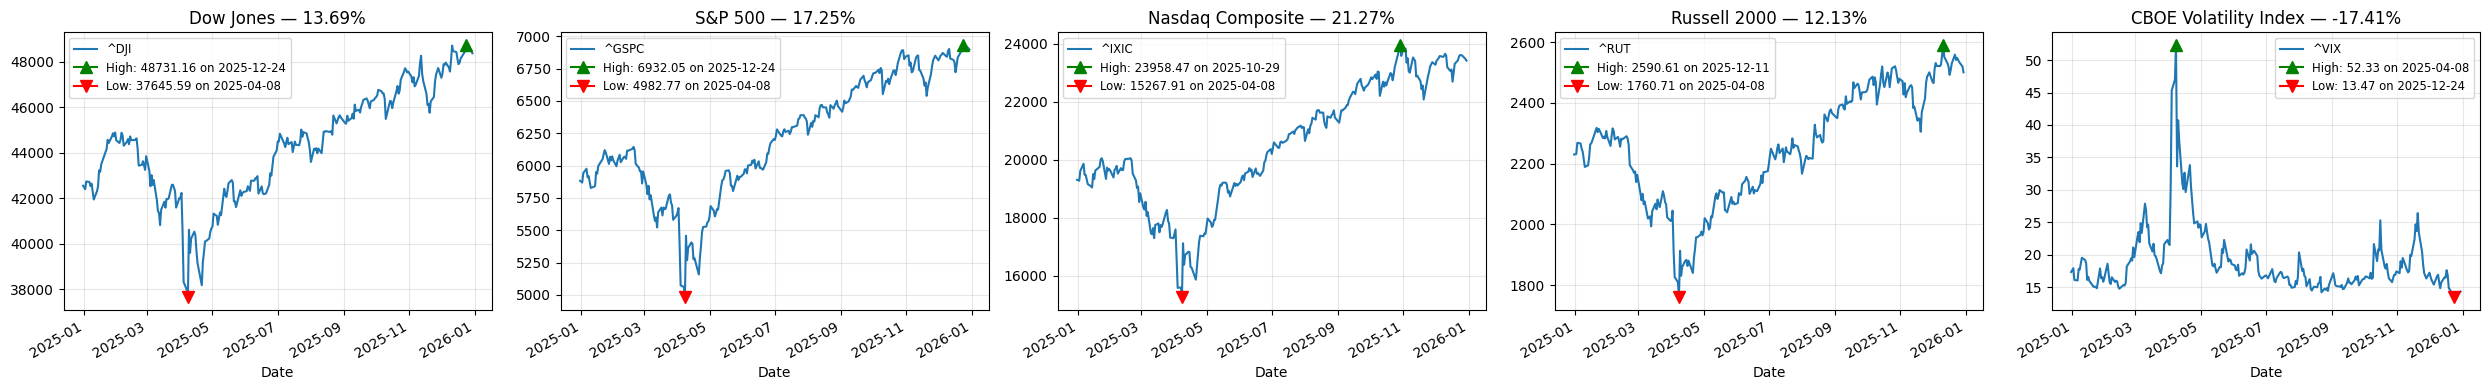

Asset Class: US Cyclic Sectors 


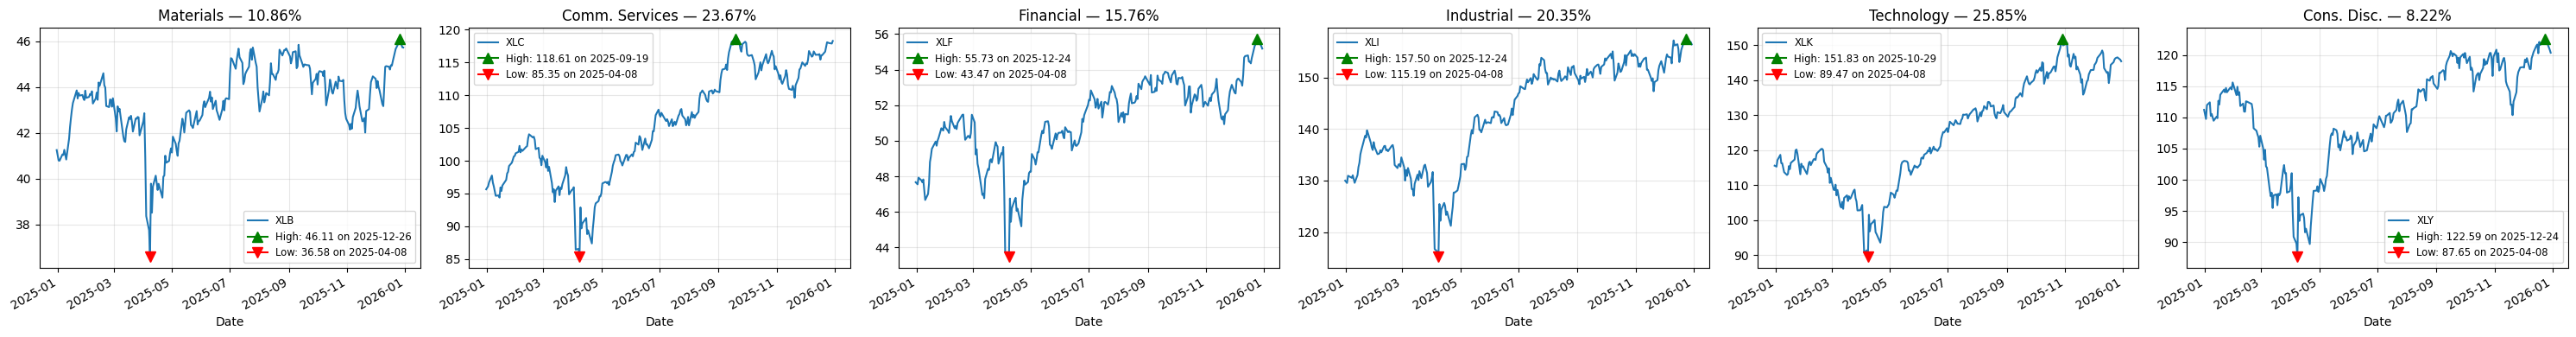

Asset Class: US Defensive Sectors


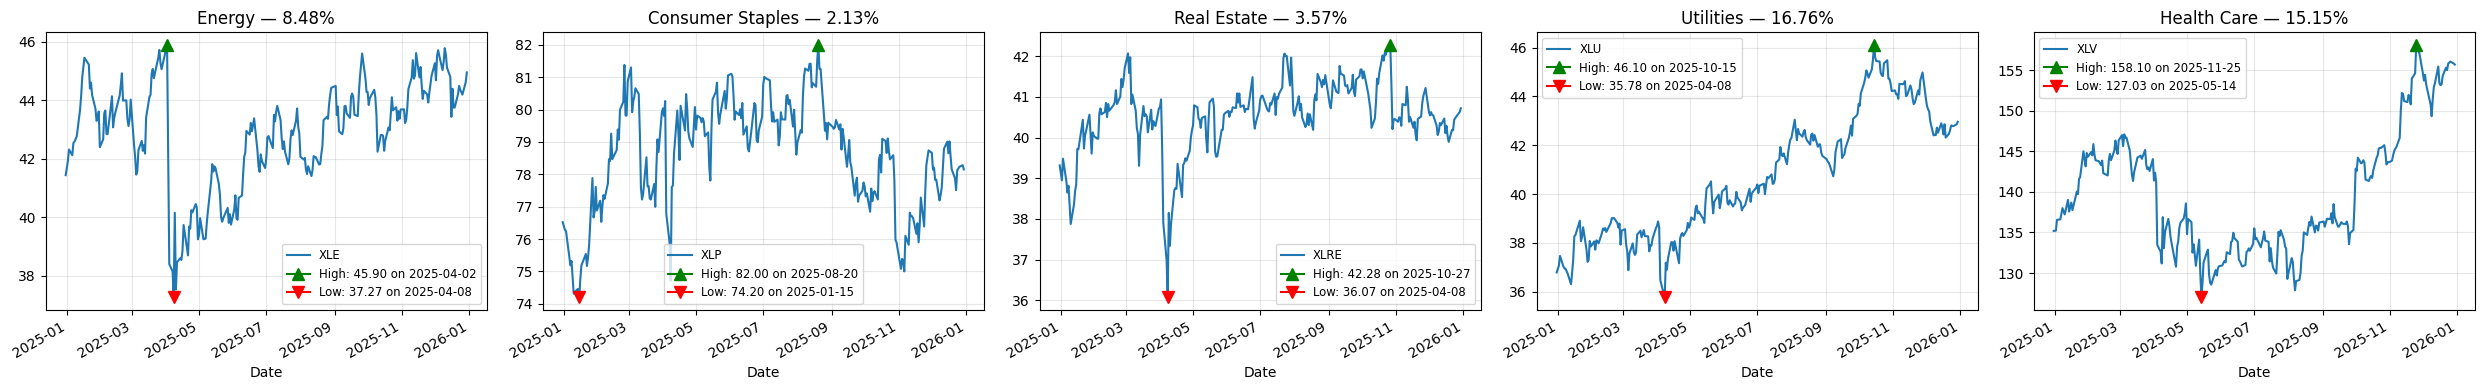

Asset Class: Ex US Equities


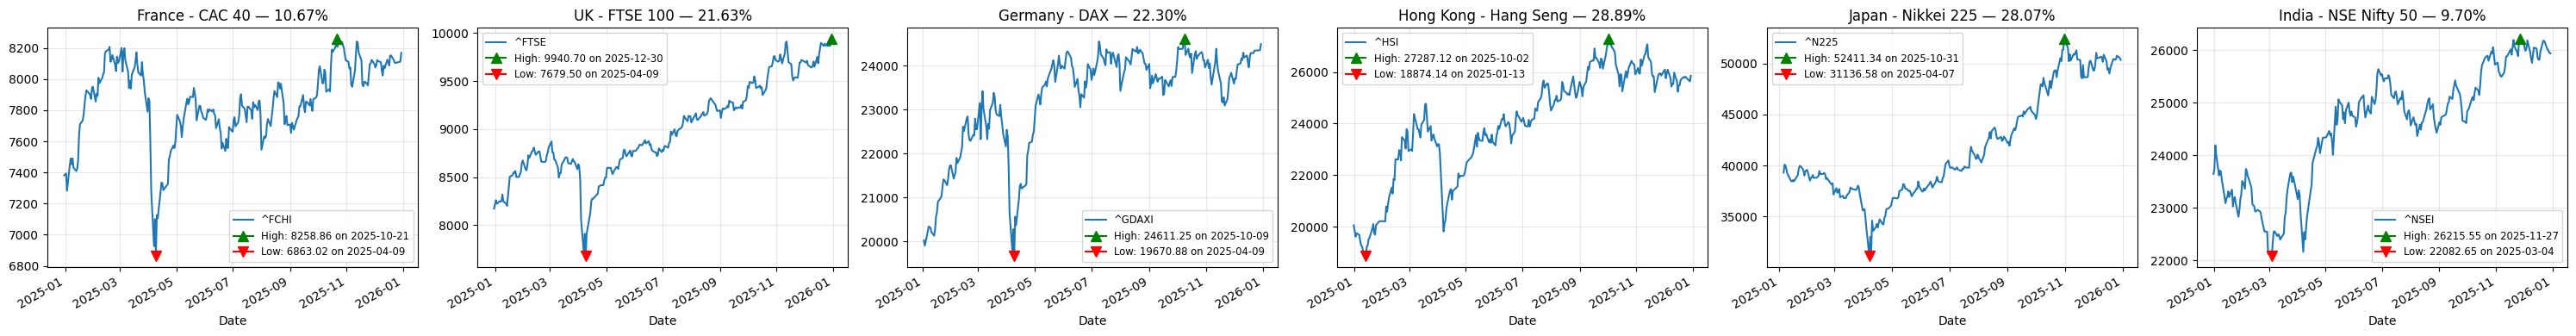

Asset Class: US Rates


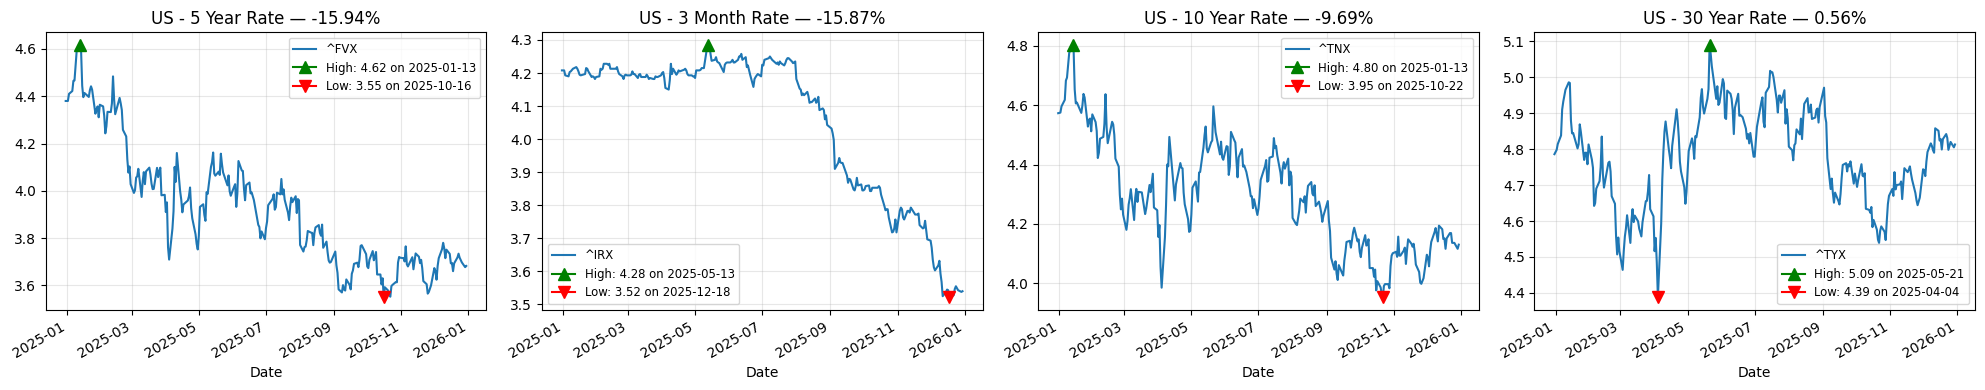

Asset Class: FX


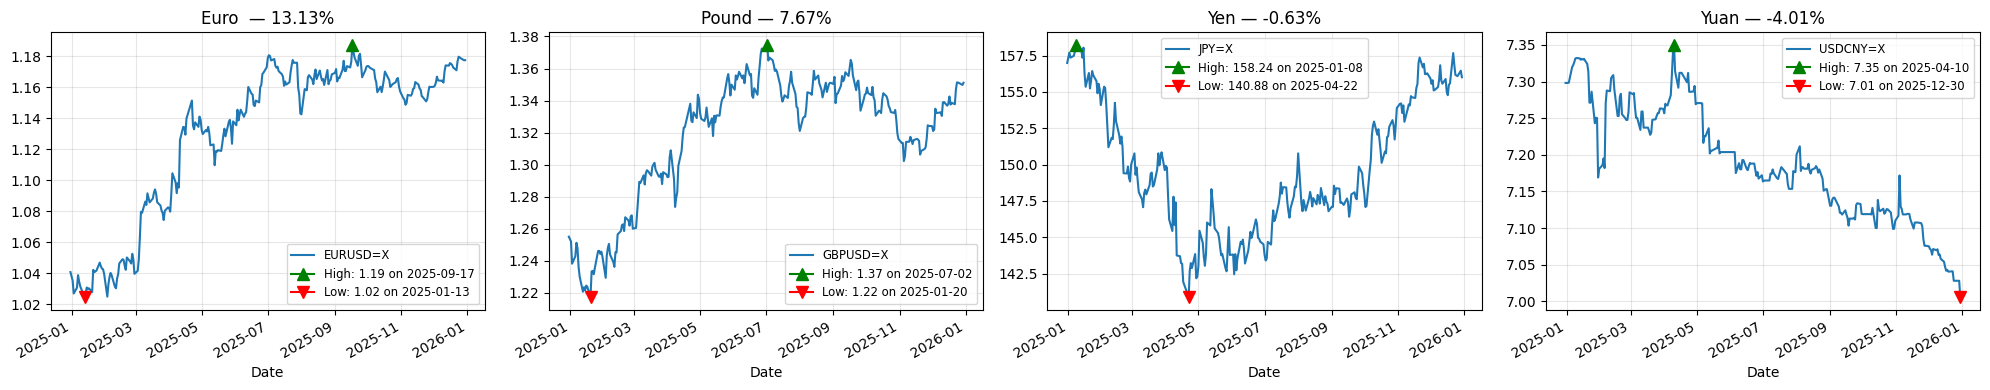

Asset Class: Commodity


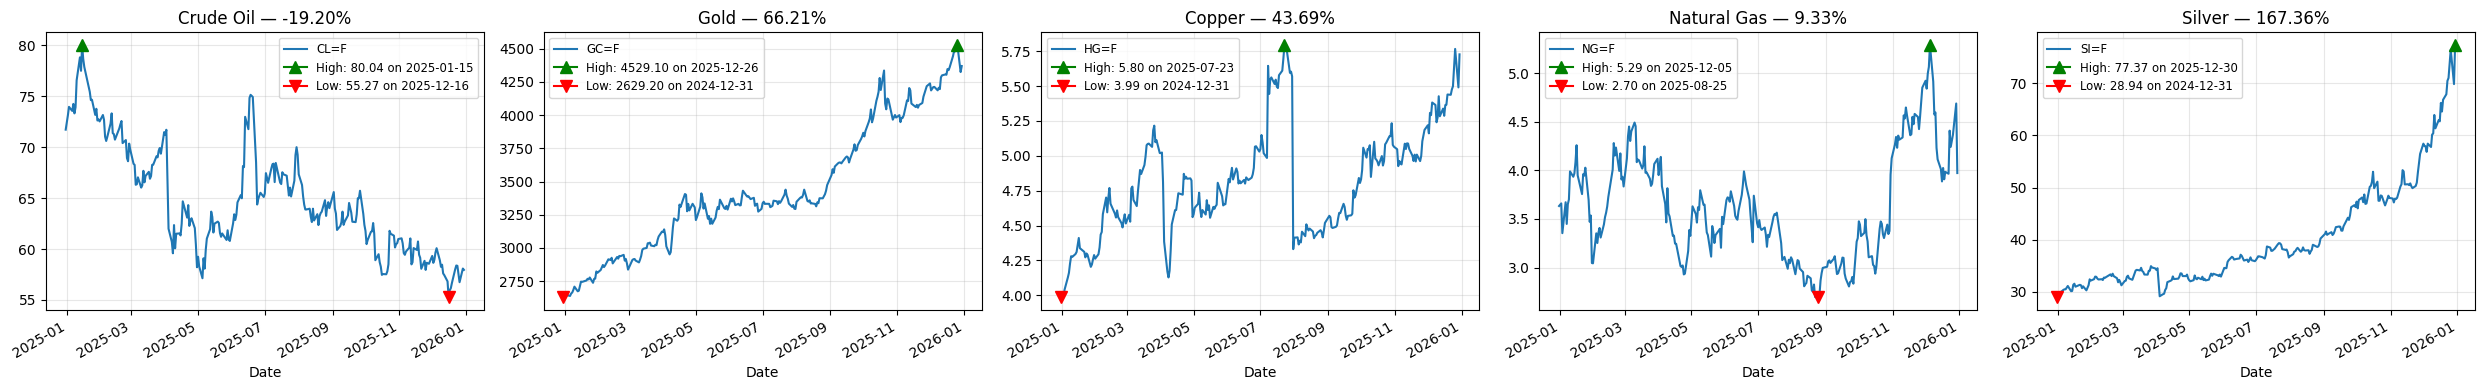

Asset Class: Crypto


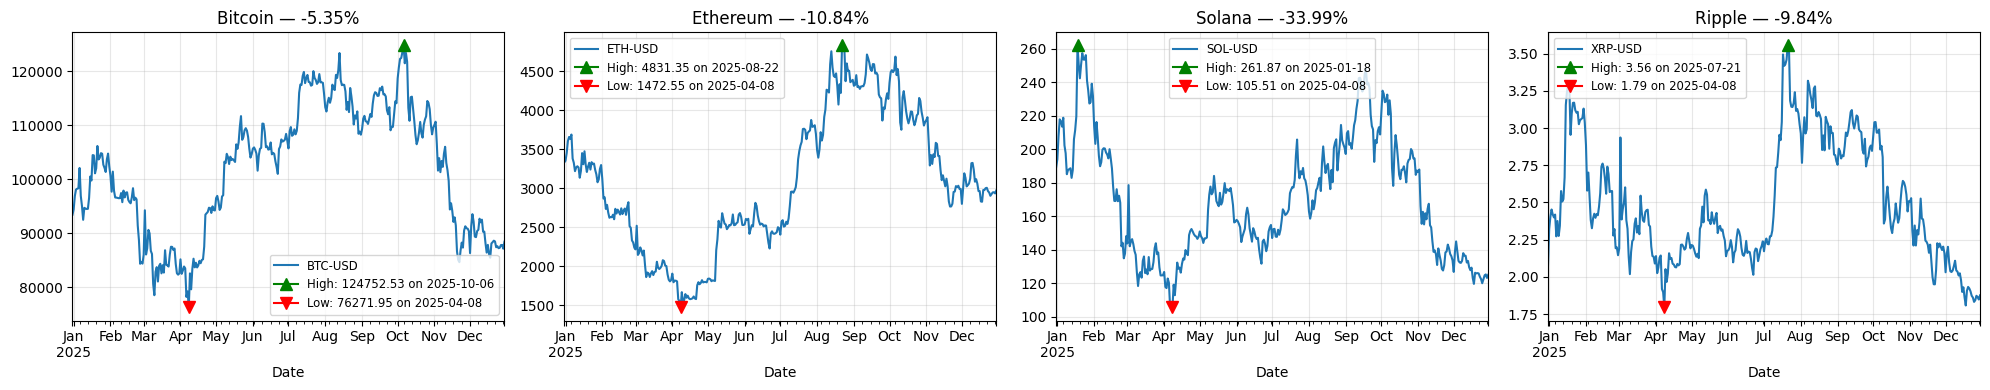

In [12]:
# Display data and charts
for asset_class, df in dashboard_data.items():
    print(f"Asset Class: {asset_class}")
    fig, axes = plt.subplots(ncols=len(df.columns), nrows=1, figsize=(5 * len(df.columns),4))

    # Normalize axes to a list when only one subplot exists
    axes_list = axes if hasattr(axes, '__len__') else [axes]

    for i, column in enumerate(df.columns):
        ax = axes_list[i]
        series = df[column].dropna()
        if series.empty:
            ax.set_title(ticker_names.get(column, column))
            continue

        # Ensure chronological order
        series = series.sort_index()

        # Compute percent return over the period (first available -> last available)
        try:
            start_val = series.iloc[0]
            end_val = series.iloc[-1]
            pct_return = (end_val / start_val - 1) * 100
        except Exception:
            pct_return = float('nan')

        # Plot series with percent return in title
        series.plot(ax=ax, title=f"{ticker_names.get(column, column)} — {pct_return:.2f}%", xlabel=None)

        # Find high and low points
        high_idx = series.idxmax()
        high_val = series.max()
        low_idx = series.idxmin()
        low_val = series.min()

        # Plot markers for high and low
        ax.plot(high_idx, high_val, marker='^', color='green', markersize=8, label=f"High: {high_val:.2f} on {pd.to_datetime(high_idx).strftime('%Y-%m-%d')}")
        ax.plot(low_idx, low_val, marker='v', color='red', markersize=8, label=f"Low: {low_val:.2f} on {pd.to_datetime(low_idx).strftime('%Y-%m-%d')}")

        # Add legend and grid
        ax.legend(fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()  # Adjust subplot spacing
    plt.show()